In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/olympics/dataset_olympics.csv")
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  str    
 2   Sex     70000 non-null  str    
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  str    
 7   NOC     70000 non-null  str    
 8   Games   70000 non-null  str    
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  str    
 11  City    70000 non-null  str    
 12  Sport   70000 non-null  str    
 13  Event   70000 non-null  str    
 14  Medal   9690 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 8.0 MB


In [5]:
data.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [6]:
data.describe(include=["object"])

/var/folders/bv/bsq_bm7d4w32q1dwcyfy55sh0000gn/T/ipykernel_51747/2389127942.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=["object"])


,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,70000,70000,70000,70000,70000,70000,70000,70000,70000,9690
unique,35556,2,827,226,51,2,42,65,744,3
top,Oksana Aleksandrovna Chusovitina,M,United States,USA,2016 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,29,51877,4979,5216,3675,58467,6034,10629,1738,3292


In [ ]:
# look for missing data
data.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [8]:
# We will not change any missing data because we are missing nothing critical

In [9]:
data.duplicated().sum()

np.int64(383)

In [ ]:
# remove duplicates
data.drop_duplicates(inplace=True)

In [11]:
data.duplicated().sum()

np.int64(0)

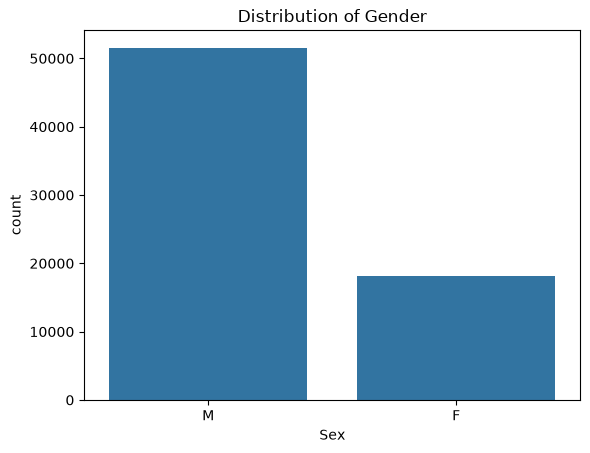

In [12]:
sns.countplot(data=data, x="Sex")
plt.title("Distribution of Gender")
plt.show()

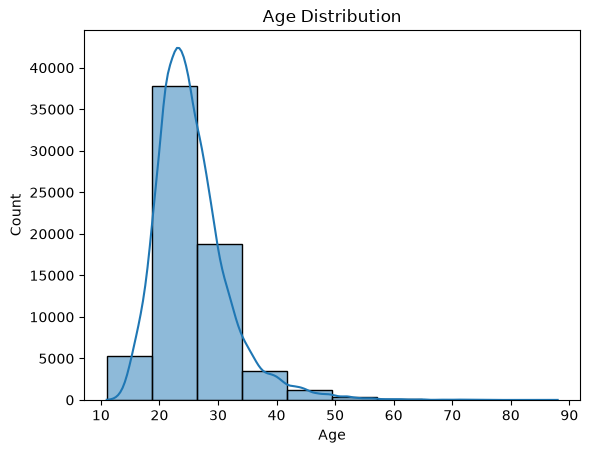

In [14]:
sns.histplot(data=data, x="Age", bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

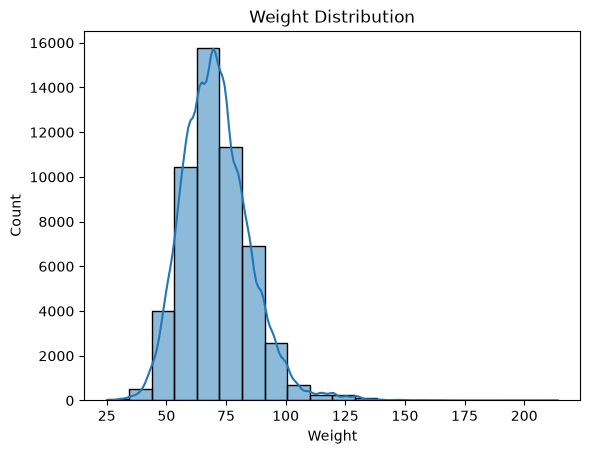

In [15]:
sns.histplot(data=data, x="Weight", bins=20, kde=True)
plt.title("Weight Distribution")
plt.show()

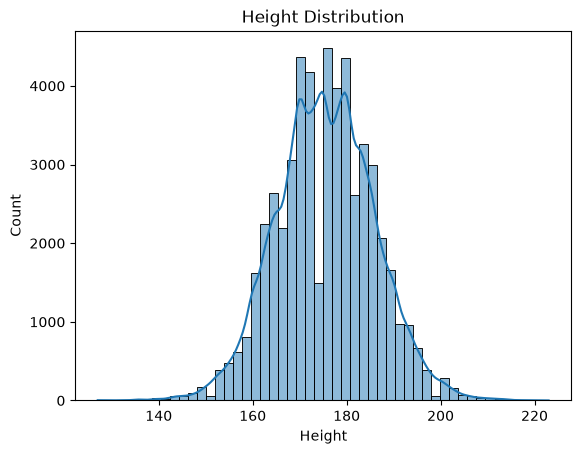

In [18]:
sns.histplot(data=data, x="Height", bins=50, kde=True)
plt.title("Height Distribution")
plt.show()

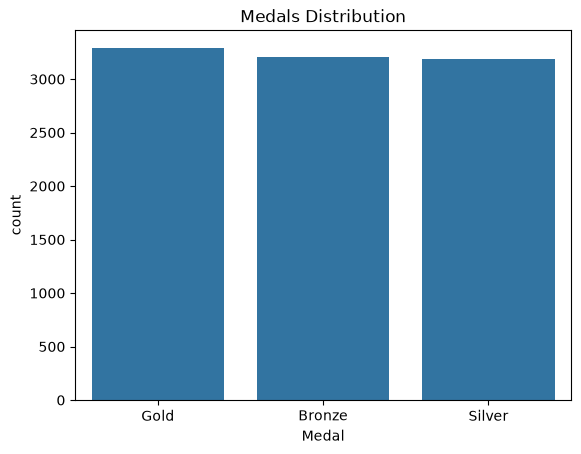

In [20]:
sns.countplot(data=data, x="Medal")
plt.title("Medals Distribution")
plt.show()

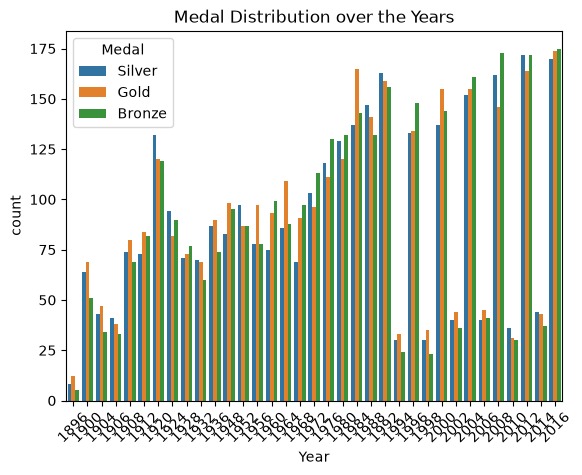

In [21]:
sns.countplot(data=data, x="Year", hue="Medal")
plt.title("Medal Distribution over the Years")
plt.xticks(rotation=45)
plt.show()

In [23]:
year_avg_age = data.groupby("Year")["Age"].mean()
year_avg_age

Year
1896    23.029412
1900    29.119883
1904    27.063241
1906    26.989474
1908    27.000000
1912    27.965552
1920    29.241135
1924    28.252267
1928    27.973564
1932    29.606987
1936    27.245665
1948    28.363170
1952    26.273684
1956    26.316156
1960    25.136156
1964    24.852107
1968    24.316722
1972    24.126448
1976    23.656820
1980    23.312364
1984    24.060328
1988    24.257374
1992    24.637827
1994    24.487516
1996    25.338210
1998    25.143860
2000    25.435177
2002    26.029095
2004    25.780111
2006    26.091716
2008    25.685148
2010    26.150776
2012    25.993485
2014    26.082814
2016    26.259592
Name: Age, dtype: float64

In [31]:
sport_median_height = data.groupby("Sport")["Height"].median()
sport_median_height.max()

np.float64(190.0)

In [38]:
print(sport_median_height[sport_median_height == sport_median_height.median()])
print(sport_median_height[sport_median_height == sport_median_height.min()])
print(sport_median_height[sport_median_height == sport_median_height.max()])

Sport
Badminton        175.0
Biathlon         175.0
Curling          175.0
Equestrianism    175.0
Golf             175.0
Judo             175.0
Triathlon        175.0
Name: Height, dtype: float64
Sport
Gymnastics    164.0
Name: Height, dtype: float64
Sport
Basketball    190.0
Name: Height, dtype: float64


In [ ]:
country_gender_count = data.groupby(["NOC", "Sex"])["ID"].count()
country_gender_count

NOC  Sex
AFG  M       38
AHO  F        6
     M       27
ALB  F        4
     M        7
           ... 
YUG  M      455
ZAM  F        3
     M       40
ZIM  F       41
     M       47
Name: ID, Length: 432, dtype: int64

In [47]:
country_gold_medals = data[data["Medal"] == "Gold"].groupby("NOC")["Medal"].count()
print(country_gold_medals)
print(country_gold_medals[country_gold_medals == country_gold_medals.max()])
print(country_gold_medals[country_gold_medals == country_gold_medals.min()])

NOC
ALG      1
ANZ      7
ARG     25
ARM      1
AUS     98
      ... 
URU     13
USA    747
UZB      4
YUG     31
ZIM      7
Name: Medal, Length: 84, dtype: int64
NOC
USA    747
Name: Medal, dtype: int64
NOC
ALG    1
ARM    1
AZE    1
CIV    1
COL    1
DOM    1
GEO    1
IOA    1
IRI    1
JOR    1
LUX    1
MGL    1
NEP    1
POR    1
THA    1
UAE    1
UGA    1
Name: Medal, dtype: int64


In [54]:
sport_gender_avg_weight = data.groupby(["Sport", "Sex"])["Weight"].mean()
sport_gender_avg_weight["Wrestling"]["F"]

np.float64(58.16901408450704)

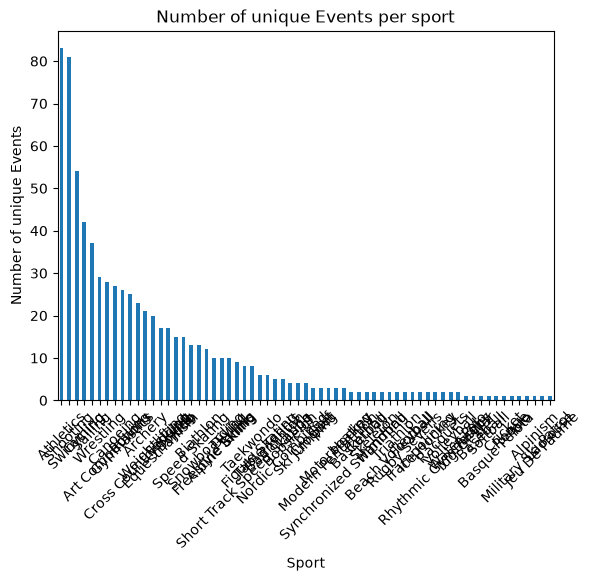

In [58]:
sport_event_count = data.groupby("Sport")["Event"].nunique().sort_values(ascending=False)
sport_event_count.plot(kind="bar")
plt.title("Number of unique Events per sport")
plt.xlabel("Sport")
plt.ylabel("Number of unique Events")
plt.xticks(rotation = 45)
plt.show()

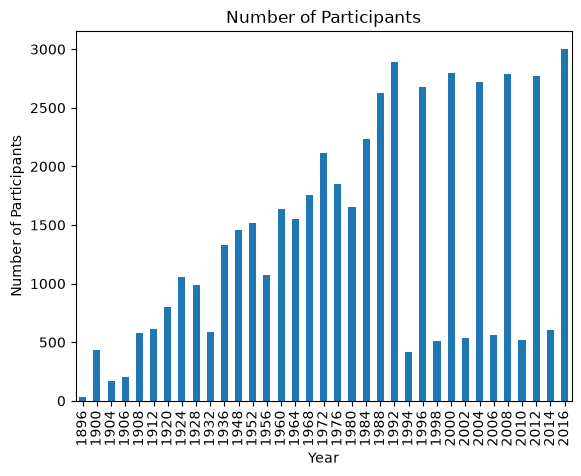

In [62]:
year_participant_count = data.groupby("Year")["ID"].nunique()
year_participant_count.plot(kind="bar")
plt.title("Number of Participants")
plt.xlabel("Year")
plt.ylabel("Number of Participants")
plt.show()

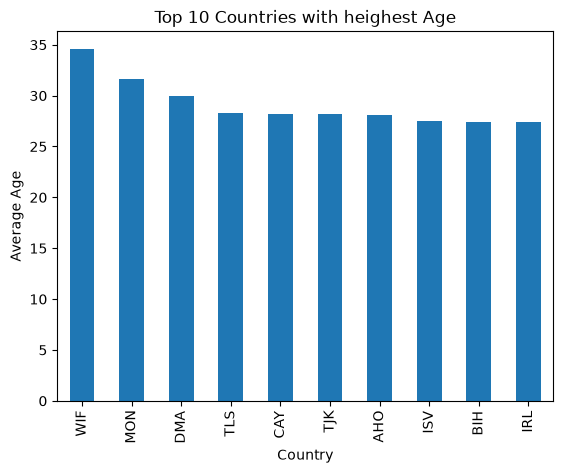

In [63]:
country_avg_age = data.groupby("NOC")["Age"].mean().sort_values(ascending=False)
country_avg_age.head(10).plot(kind="bar")
plt.title("Top 10 Countries with heighest Age")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.show()

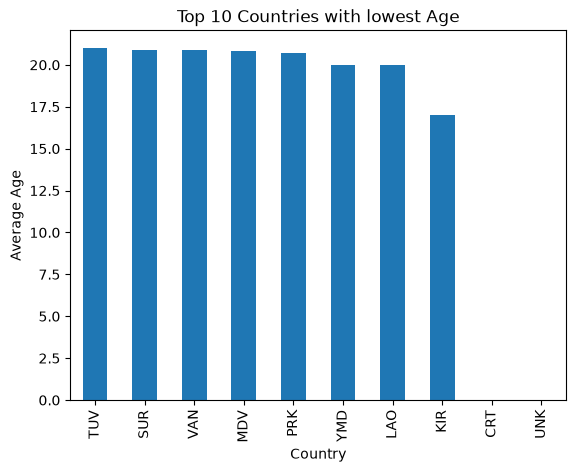

In [64]:
country_avg_age = data.groupby("NOC")["Age"].mean().sort_values(ascending=False)
country_avg_age.tail(10).plot(kind="bar")
plt.title("Top 10 Countries with lowest Age")
plt.xlabel("Country")
plt.ylabel("Average Age")
plt.show()

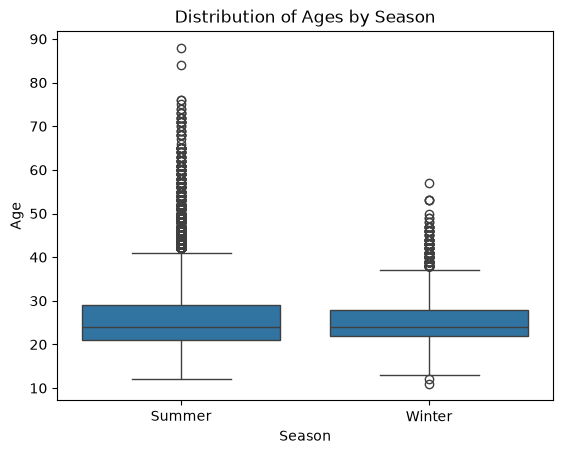

In [65]:
sns.boxplot(data=data, x="Season", y="Age")
plt.title("Distribution of Ages by Season")
plt.xlabel("Season")
plt.ylabel("Age")
plt.show()

/var/folders/bv/bsq_bm7d4w32q1dwcyfy55sh0000gn/T/ipykernel_51747/4083370738.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="Medal", y="Height", palette="Set2")


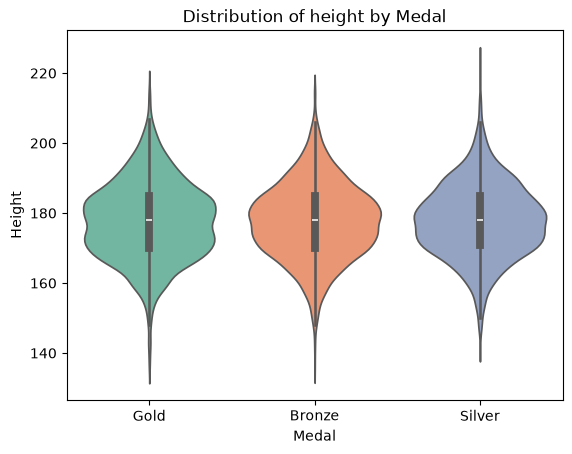

In [66]:
sns.violinplot(data=data, x="Medal", y="Height", palette="Set2")
plt.title("Distribution of height by Medal")
plt.xlabel("Medal")
plt.ylabel("Height")
plt.show()

In [67]:
most_medals_country = data["NOC"].value_counts().idxmax()
print("Most winning country: ", most_medals_country)

Most winning country:  USA


In [68]:
best_athlete = data["Name"].value_counts().idxmax()
print("Best Athlete: ", best_athlete)

Best Athlete:  Oksana Aleksandrovna Chusovitina


In [69]:
tallest_athlete = data[data["Height"] == data["Height"].max()]
print("Tallest Athlete: ")
print(tallest_athlete[["ID", "Name", "Height", "Sport"]])

Tallest Athlete: 
          ID                  Name  Height       Sport
32376  16639  Tommy Loren Burleson   223.0  Basketball


In [74]:
heaviest_athlete = data[data["Weight"] == data["Weight"].max()]
print("Fattest Athlete: ")
print(heaviest_athlete[["ID", "Name", "Height","Weight", "Sport"]])

Fattest Athlete: 
          ID               Name  Height  Weight Sport
23155  12177  Ricardo Blas, Jr.   183.0   214.0  Judo
23156  12177  Ricardo Blas, Jr.   183.0   214.0  Judo


In [73]:
lightest_athlete = data[data["Weight"] == data["Weight"].min()]
print("Slimmest Athlete: ")
print(lightest_athlete[["ID", "Name", "Height","Weight", "Sport"]])

Slimmest Athlete: 
          ID            Name  Height  Weight       Sport
40849  21049  Choi Myong-Hui   135.0    25.0  Gymnastics
40850  21049  Choi Myong-Hui   135.0    25.0  Gymnastics
40851  21049  Choi Myong-Hui   135.0    25.0  Gymnastics
40852  21049  Choi Myong-Hui   135.0    25.0  Gymnastics
40853  21049  Choi Myong-Hui   135.0    25.0  Gymnastics
40854  21049  Choi Myong-Hui   135.0    25.0  Gymnastics


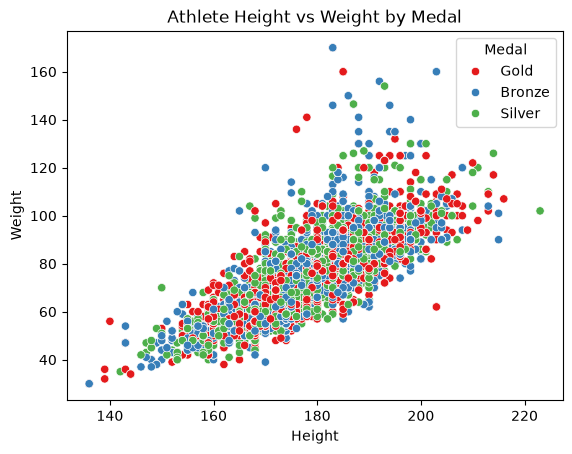

In [75]:
sns.scatterplot(data=data, x="Height", y="Weight", hue="Medal", palette="Set1")
plt.title("Athlete Height vs Weight by Medal")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.legend(title="Medal")
plt.show()

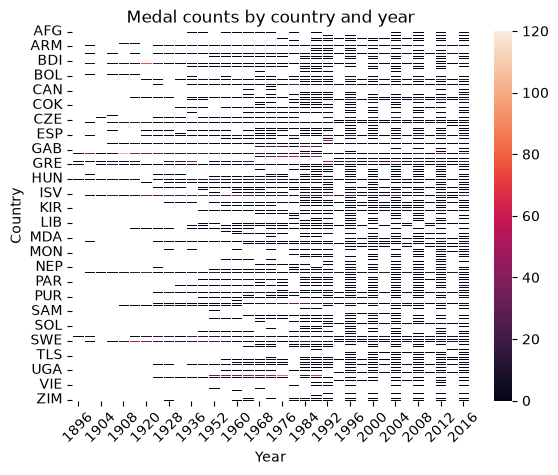

In [76]:
medals_by_country_year = data.pivot_table(index="NOC", columns="Year", values="Medal", aggfunc="count")
sns.heatmap(medals_by_country_year, linewidths=0.5)
plt.title("Medal counts by country and year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.xticks(rotation = 45)
plt.show()